# Modeling

CRISP-DM Phase 4 for **Predicting Fork-to-PR Conversion in Open-Source Repositories**.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    mean_absolute_error,
    precision_score,
    r2_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
%matplotlib inline

## 1) Select Modeling Technique

Two target formulations are used to match project success criteria from Stage 1:

- **Classification target**: `has_conversion` (binary, whether repository-season had at least one converted fork).
- **Regression target**: `fork_conversion_rate` (continuous conversion intensity).

Model candidates:
- Baseline predictors
- Logistic Regression (classification)
- Random Forest (classification and regression)
- Gradient Boosting (classification)

These models cover both interpretable linear baseline behavior and non-linear tree-based behavior that can better fit skewed activity data.

## 2) Generate Test Design

- Hold-out strategy: random train/test split (80/20, `random_state=42`).
- Primary metrics:
  - Classification: Accuracy, Macro-F1, Precision, ROC-AUC.
  - Regression: MAE, R2.
- Baselines:
  - Classification: predict majority class.
  - Regression: predict train mean conversion rate.

This gives direct comparability against naive baselines required by the report's success criteria.

In [2]:
DATA_DIRS = [Path("data"), Path("src/data"), Path("../src/data")]
DATA_BASENAME = "modeling_dataset"


def _looks_like_git_lfs_pointer(path: Path) -> bool:
    """Detect tiny text pointer files committed by Git LFS instead of real binary data."""
    try:
        head = path.read_bytes()[:64]
    except Exception:
        return False
    return head.startswith(b"version https://git-lfs.github.com/spec/v1")


candidates = []
for d in DATA_DIRS:
    candidates.append(d / f"{DATA_BASENAME}.parquet")
    candidates.append(d / f"{DATA_BASENAME}.csv")

load_errors = []
df = None
source_used = None

for p in candidates:
    if not p.exists():
        continue
    try:
        if p.suffix == ".parquet":
            if _looks_like_git_lfs_pointer(p):
                raise RuntimeError("Git LFS pointer file detected, not real parquet data")
            df = pd.read_parquet(p)
        else:
            df = pd.read_csv(p)
        source_used = p
        break
    except Exception as e:
        load_errors.append(f"{p}: {e}")

if df is None:
    err_text = "\n".join(load_errors) if load_errors else "No candidate files found"
    raise RuntimeError(
        "Could not load modeling dataset.\n"
        "Reason(s):\n"
        f"{err_text}\n\n"
        "If files are Git LFS pointers, fetch real data with:\n"
        "  git lfs pull\n"
        "or re-export `modeling_dataset.csv` from DataPreparation.ipynb."
    )

print(f"Loaded: {source_used}")
print("Shape:", df.shape)
df.head(3)

Loaded: data/modeling_dataset.parquet
Shape: (100000, 28)


,repo_name,repo_id,season,log1p_issue_comments,log1p_issue_comments_winsor,log1p_issues,log1p_issues_winsor,log1p_pushes,log1p_pushes_winsor,log1p_releases,log1p_releases_winsor,log1p_watches,log1p_watches_winsor,n_forks,n_converted_forks,fork_conversion_rate,n_pr_events,has_conversion,watches,pushes,issues,issue_comments,releases,watches_winsor,pushes_winsor,issues_winsor,issue_comments_winsor,releases_winsor
0,AutomationPanda/awesome-web-testing-playwright,3002,winter_spring,0.693147,0.693147,0.693147,0.693147,0.000000,0.000000,0.0,0.0,3.178054,3.178054,8,0,0.0,0,0,23,0,1,1,0,23.0,0.0,1.0,1.0,0.0
1,Neamar/KISS,16186,summer_autumn,4.143135,4.143135,3.828641,3.828641,3.135494,3.135494,0.0,0.0,4.007333,4.007333,10,3,0.3,35,1,54,22,45,62,0,54.0,22.0,45.0,62.0,0.0
2,magnific0/wondershaper,57159,winter_spring,2.302585,2.302585,1.098612,1.098612,0.000000,0.000000,0.0,0.0,3.401197,3.401197,6,0,0.0,0,0,29,0,2,9,0,29.0,0.0,2.0,9.0,0.0


In [3]:
# Targets
y_cls = df["has_conversion"].astype(int)
y_reg = df["fork_conversion_rate"].astype(float)

# Remove direct leakage columns from features
leak_cols = ["has_conversion", "fork_conversion_rate", "n_converted_forks", "repo_name"]
candidate_features = [c for c in df.columns if c not in leak_cols]

X = df[candidate_features].copy()

# Treat object/string/category/boolean as categorical to avoid numeric imputer errors.
cat_cols = [
    c
    for c in X.columns
    if pd.api.types.is_object_dtype(X[c])
    or pd.api.types.is_string_dtype(X[c])
    or pd.api.types.is_categorical_dtype(X[c])
    or pd.api.types.is_bool_dtype(X[c])
]
num_cols = [c for c in X.columns if c not in cat_cols]

print("Feature columns:", len(candidate_features))
print("Categorical:", cat_cols)
print("Numeric count:", len(num_cols))
print("Class balance (has_conversion):")
display(y_cls.value_counts(normalize=True).rename("share"))

Feature columns: 24
Categorical: ['season']
Numeric count: 23
Class balance (has_conversion):


has_conversion
0    0.52086
1    0.47914
Name: share, dtype: float64

## 3) Build Model

In [4]:
X_train, X_test, y_cls_train, y_cls_test, y_reg_train, y_reg_test = train_test_split(
    X, y_cls, y_reg, test_size=0.2, random_state=42, stratify=y_cls
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), num_cols),
        (
            "cat",
            Pipeline([
                ("imp", SimpleImputer(strategy="most_frequent")),
                ("oh", OneHotEncoder(handle_unknown="ignore")),
            ]),
            cat_cols,
        ),
    ],
    remainder="drop",
)

# Classification baselines and models
majority_class = int(y_cls_train.mode()[0])
baseline_cls_pred = np.full_like(y_cls_test, fill_value=majority_class)

clf_models = {
    "logistic_regression": Pipeline(
        [
            ("prep", preprocess),
            ("model", LogisticRegression(max_iter=1200, class_weight="balanced", n_jobs=None)),
        ]
    ),
    "random_forest_clf": Pipeline(
        [
            ("prep", preprocess),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=250,
                    max_depth=14,
                    min_samples_leaf=2,
                    random_state=42,
                    n_jobs=-1,
                    class_weight="balanced_subsample",
                ),
            ),
        ]
    ),
    "gradient_boosting_clf": Pipeline(
        [
            ("prep", preprocess),
            ("model", GradientBoostingClassifier(random_state=42)),
        ]
    ),
}

cls_results = []
for name, model in clf_models.items():
    model.fit(X_train, y_cls_train)
    pred = model.predict(X_test)
    if hasattr(model.named_steps["model"], "predict_proba"):
        proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_cls_test, proba)
    else:
        auc = np.nan
    cls_results.append(
        {
            "model": name,
            "accuracy": accuracy_score(y_cls_test, pred),
            "macro_f1": f1_score(y_cls_test, pred, average="macro"),
            "precision": precision_score(y_cls_test, pred, zero_division=0),
            "roc_auc": auc,
        }
    )

baseline_cls = {
    "model": "baseline_majority",
    "accuracy": accuracy_score(y_cls_test, baseline_cls_pred),
    "macro_f1": f1_score(y_cls_test, baseline_cls_pred, average="macro"),
    "precision": precision_score(y_cls_test, baseline_cls_pred, zero_division=0),
    "roc_auc": np.nan,
}

cls_table = pd.DataFrame([baseline_cls] + cls_results).sort_values("macro_f1", ascending=False)
display(cls_table)

# Regression baselines and models
baseline_mean = float(y_reg_train.mean())
baseline_reg_pred = np.full_like(y_reg_test, baseline_mean, dtype=float)

reg_models = {
    "linear_regression": Pipeline([("prep", preprocess), ("model", LinearRegression())]),
    "random_forest_reg": Pipeline(
        [
            ("prep", preprocess),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=250,
                    max_depth=16,
                    min_samples_leaf=2,
                    random_state=42,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
}

reg_results = []
for name, model in reg_models.items():
    model.fit(X_train, y_reg_train)
    pred = model.predict(X_test)
    reg_results.append(
        {
            "model": name,
            "mae": mean_absolute_error(y_reg_test, pred),
            "r2": r2_score(y_reg_test, pred),
        }
    )

baseline_reg = {
    "model": "baseline_mean",
    "mae": mean_absolute_error(y_reg_test, baseline_reg_pred),
    "r2": r2_score(y_reg_test, baseline_reg_pred),
}

reg_table = pd.DataFrame([baseline_reg] + reg_results).sort_values("mae")
display(reg_table)

,model,accuracy,macro_f1,precision,roc_auc
3,gradient_boosting_clf,0.85140,0.851365,0.808205,0.932880
2,random_forest_clf,0.84805,0.847971,0.800957,0.932143
1,logistic_regression,0.77920,0.777745,0.793613,0.853098
0,baseline_majority,0.52085,0.342473,0.000000,NaN


,model,mae,r2
2,random_forest_reg,0.074961,0.631287
1,linear_regression,0.124935,0.352412
0,baseline_mean,0.158946,-0.000155


## 4) Assess Model

The assessment compares each model against the stage success criteria:

- **Classification**: macro-F1 should exceed naive baseline; precision should be meaningful under class imbalance.
- **Regression**: MAE should be lower than mean baseline and R2 should be positive on test data.

In addition, we inspect predicted probabilities for qualitative calibration behavior and report the top candidate model for each target formulation.

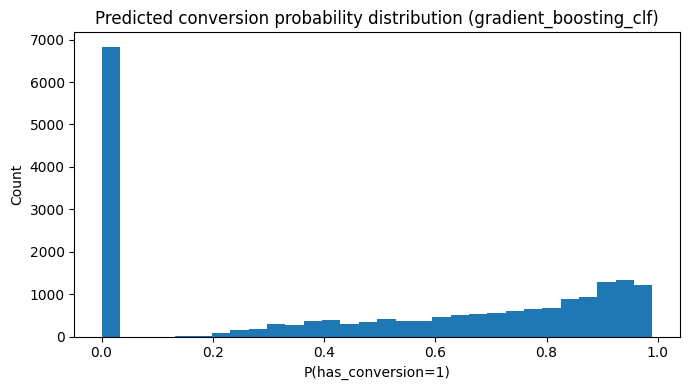

Best classification model: gradient_boosting_clf
Best regression model: random_forest_reg

Quick interpretation:
- If best classification macro-F1 > baseline, model captures conversion signal beyond class prior.
- If best regression MAE < baseline and R2 > 0, model improves over naive mean-rate prediction.


In [5]:
# Refit best classification model for quick diagnostics plot
best_cls_name = cls_table.iloc[0]["model"]
if best_cls_name != "baseline_majority":
    best_cls_model = clf_models[best_cls_name]
    best_cls_model.fit(X_train, y_cls_train)
    if hasattr(best_cls_model.named_steps["model"], "predict_proba"):
        p = best_cls_model.predict_proba(X_test)[:, 1]
        plt.figure(figsize=(7, 4))
        plt.hist(p, bins=30)
        plt.title(f"Predicted conversion probability distribution ({best_cls_name})")
        plt.xlabel("P(has_conversion=1)")
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()

print("Best classification model:", best_cls_name)
print("Best regression model:", reg_table.iloc[0]["model"])

print("\nQuick interpretation:")
print("- If best classification macro-F1 > baseline, model captures conversion signal beyond class prior.")
print("- If best regression MAE < baseline and R2 > 0, model improves over naive mean-rate prediction.")